# BCI Competition IV Dataset 2a — EEGNet (Improved Pipeline)
## Changes from v1:
- **Step 7**: Data Augmentation added (3× training trials via Gaussian noise)
- **Step 8**: Training replaced with validation-monitored loop + early stopping + label smoothing + weight decay + cosine LR
- **Step 9**: Evaluation unchanged (official eval set with true labels)
- **Step 10**: All-subject loop uses the improved pipeline

Steps 1–6 are identical to the corrected notebook.

## Step 1: Mount Drive & Verify Files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATA_PATH        = "/content/drive/MyDrive/BCI_IV_2a"
TRUE_LABELS_PATH = "/content/drive/MyDrive/BCI_IV_2a/true_labels"

print("=== GDF files ===")
gdf_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.gdf')])
for f in gdf_files:
    print(f)

print("\n=== True label files ===")
if os.path.exists(TRUE_LABELS_PATH):
    for f in sorted(os.listdir(TRUE_LABELS_PATH)):
        print(f)
else:
    print("ERROR: true_labels folder not found!")
    print("Download from: https://www.bbci.de/competition/iv/results/ds2a/true_labels.zip")

=== GDF files ===
A01E.gdf
A01T.gdf
A02E.gdf
A02T.gdf
A03E.gdf
A03T.gdf
A04E.gdf
A04T.gdf
A05E.gdf
A05T.gdf
A06E.gdf
A06T.gdf
A07E.gdf
A07T.gdf
A08E.gdf
A08T.gdf
A09E.gdf
A09T.gdf

=== True label files ===
A01E.mat
A01T.mat
A02E.mat
A02T.mat
A03E.mat
A03T.mat
A04E.mat
A04T.mat
A05E.mat
A05T.mat
A06E.mat
A06T.mat
A07E.mat
A07T.mat
A08E.mat
A08T.mat
A09E.mat
A09T.mat


## Step 2: Install & Import Libraries

In [3]:
!pip install mne scipy torch torchvision scikit-learn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 92.8 MB/s eta 0:00:00


In [4]:
import os
import copy
import numpy as np
import mne
from scipy.io import loadmat

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, \
                            confusion_matrix, classification_report

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

mne.set_log_level('WARNING')
print("All libraries loaded successfully.")

All libraries loaded successfully.


## Step 3: Data Loading Functions
- `load_train_data()` — reads A0xT.gdf, labels from events 769–772
- `load_eval_data()`  — reads A0xE.gdf, labels from true_labels .mat file (cue event = 783)

In [5]:
# ─────────────────────────────────────────────────────────────
# TRAINING DATA LOADER  (A0xT.gdf)
# ─────────────────────────────────────────────────────────────
def load_train_data(file_path, tmin=3.0, tmax=6.0):
    """
    Load training GDF. Labels extracted from embedded events 769-772.
    BCI IV 2a timing: cue at t=2s, MI period t=3-6s.
    """
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=False)

    eog_channels = ['EOG-left', 'EOG-central', 'EOG-right']
    existing_eog = [ch for ch in eog_channels if ch in raw.ch_names]
    raw.drop_channels(existing_eog)

    raw.filter(8., 30., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)

    mi_event_map = {'769': 0, '770': 1, '771': 2, '772': 3}
    code_to_name = {v: k for k, v in event_dict.items()}

    selected_events, labels = [], []
    for ev in events:
        name = code_to_name.get(ev[2], None)
        if name in mi_event_map:
            selected_events.append(ev)
            labels.append(mi_event_map[name])

    selected_events = np.array(selected_events, dtype=int)
    labels          = np.array(labels, dtype=int)

    print(f"  Trials found: {len(labels)}")

    epochs = mne.Epochs(raw, selected_events, tmin=tmin, tmax=tmax,
                        baseline=None, preload=True, verbose=False)

    n_dropped = len(labels) - len(epochs)
    if n_dropped > 0:
        print(f"  WARNING: {n_dropped} epoch(s) dropped (boundary).")

    data   = epochs.get_data()
    labels = labels[:data.shape[0]]

    print(f"  Shape: {data.shape} | Classes: { {i: int(np.sum(labels==i)) for i in range(4)} }")
    return data, labels


# ─────────────────────────────────────────────────────────────
# EVALUATION DATA LOADER  (A0xE.gdf + true_labels A0xE.mat)
# ─────────────────────────────────────────────────────────────
def load_eval_data(gdf_path, mat_path, tmin=3.0, tmax=6.0):
    """
    Load evaluation GDF + true labels from .mat.
    Eval files use event 783 (class unknown) as cue marker.
    """
    mat         = loadmat(mat_path)
    true_labels = mat['classlabel'].flatten().astype(int) - 1
    print(f"  True labels: {len(true_labels)} | Classes: { {i: int(np.sum(true_labels==i)) for i in range(4)} }")

    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)

    eog_channels = ['EOG-left', 'EOG-central', 'EOG-right']
    existing_eog = [ch for ch in eog_channels if ch in raw.ch_names]
    raw.drop_channels(existing_eog)

    raw.filter(8., 30., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)

    cue_code = event_dict.get('783', None)
    if cue_code is None:
        raise ValueError(f"Cue event '783' not found. Available: {list(event_dict.keys())}")

    cue_events = events[events[:, 2] == cue_code]
    print(f"  Cue events (783) in GDF: {len(cue_events)}")

    if len(cue_events) != len(true_labels):
        n = min(len(cue_events), len(true_labels))
        cue_events, true_labels = cue_events[:n], true_labels[:n]
        print(f"  Truncated to {n} trials.")

    epochs = mne.Epochs(raw, cue_events, tmin=tmin, tmax=tmax,
                        baseline=None, preload=True, verbose=False)

    n_dropped = len(true_labels) - len(epochs)
    if n_dropped > 0:
        print(f"  WARNING: {n_dropped} epoch(s) dropped (boundary).")

    data        = epochs.get_data()
    true_labels = true_labels[:data.shape[0]]

    print(f"  Shape: {data.shape}")
    return data, true_labels

## Step 4: PyTorch Dataset Class

In [6]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Step 5: EEGNet Model
- Dynamic FC size (no hardcoding)
- `n_channels` and `n_samples` passed as arguments so it adapts automatically

In [7]:
class EEGNet(nn.Module):

    def __init__(self, num_classes=4, n_channels=22, n_samples=751,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()

        # Block 1: Temporal Convolution (~250ms kernel at 250Hz)
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )

        # Block 2: Depthwise Spatial Convolution
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout)
        )

        # Block 3: Separable Convolution
        self.separable = nn.Sequential(
            nn.Conv2d(F1 * D, F2, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        # Compute FC input size dynamically via dummy forward pass
        self._fc_input_size = self._get_fc_size(n_channels, n_samples)
        self.fc = nn.Linear(self._fc_input_size, num_classes)

    def _get_fc_size(self, n_channels, n_samples):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.depthwise(x)
            x = self.separable(x)
        return int(np.prod(x.shape[1:]))

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwise(x)
        x = self.separable(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)

## Step 6: Load Subject Data
Change `SUBJECT` to 1–9 to process different subjects.

In [8]:
SUBJECT = 1

train_gdf = os.path.join(DATA_PATH, f"A0{SUBJECT}T.gdf")
eval_gdf  = os.path.join(DATA_PATH, f"A0{SUBJECT}E.gdf")
eval_mat  = os.path.join(TRUE_LABELS_PATH, f"A0{SUBJECT}E.mat")

print(f"Subject : A0{SUBJECT}")
print(f"Train   : {train_gdf}  exists={os.path.exists(train_gdf)}")
print(f"Eval GDF: {eval_gdf}   exists={os.path.exists(eval_gdf)}")
print(f"Eval MAT: {eval_mat}   exists={os.path.exists(eval_mat)}")

print("\n── Loading TRAINING data ──")
X_train_raw, y_train = load_train_data(train_gdf)

print("\n── Loading EVALUATION data ──")
X_eval_raw, y_eval = load_eval_data(eval_gdf, eval_mat)

Subject : A01
Train   : /content/drive/MyDrive/BCI_IV_2a/A01T.gdf  exists=True
Eval GDF: /content/drive/MyDrive/BCI_IV_2a/A01E.gdf   exists=True
Eval MAT: /content/drive/MyDrive/BCI_IV_2a/true_labels/A01E.mat   exists=True

── Loading TRAINING data ──


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Trials found: 288
  Shape: (287, 22, 751) | Classes: {0: 71, 1: 72, 2: 72, 3: 72}

── Loading EVALUATION data ──
  True labels: 288 | Classes: {0: 72, 1: 72, 2: 72, 3: 72}


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Cue events (783) in GDF: 288
  Shape: (287, 22, 751)


In [9]:
# ── Normalize using TRAINING statistics only ─────────────────
mean = np.mean(X_train_raw, axis=(0, 2), keepdims=True)
std  = np.std(X_train_raw,  axis=(0, 2), keepdims=True)
std  = np.where(std < 1e-8, 1e-8, std)

X_train_norm = (X_train_raw - mean) / std
X_eval_norm  = (X_eval_raw  - mean) / std

print(f"Train — mean: {np.mean(X_train_norm):.6f}, std: {np.std(X_train_norm):.6f}")
print(f"Eval  — mean: {np.mean(X_eval_norm):.6f},  std: {np.std(X_eval_norm):.6f}")

# ── Add CNN channel dimension: (N, 22, T) → (N, 1, 22, T) ───
X_train_norm = X_train_norm[:, np.newaxis, :, :]
X_eval_norm  = X_eval_norm[:, np.newaxis, :, :]

N_CHANNELS = X_train_norm.shape[2]
N_SAMPLES  = X_train_norm.shape[3]

print(f"\nTrain shape : {X_train_norm.shape}")
print(f"Eval  shape : {X_eval_norm.shape}")
print(f"N_CHANNELS  : {N_CHANNELS}")
print(f"N_SAMPLES   : {N_SAMPLES}")

Train — mean: 0.000000, std: 1.000000
Eval  — mean: 0.000369,  std: 0.987606

Train shape : (287, 1, 22, 751)
Eval  shape : (287, 1, 22, 751)
N_CHANNELS  : 22
N_SAMPLES   : 751


## Step 7: Data Augmentation  ← NEW

**Why:** Only ~287 training trials (72 per class) is very small for deep learning.
We triple the dataset by adding Gaussian noise copies of each trial.

**Applied only to training data. Eval data is never augmented.**

- `noise_std=0.05` → noise = 5% of signal std (subtle perturbation)
- `n_augment=2`    → 2 noisy copies per trial → 3× total trials

In [10]:
def augment_eeg(X, y, noise_std=0.05, n_augment=2, seed=42):
    """
    Expand training set by adding Gaussian noise copies.

    Args:
        X          : array (N, 1, channels, time)
        y          : array (N,)
        noise_std  : noise level as fraction of signal std
        n_augment  : number of noisy copies per original trial
        seed       : random seed for reproducibility

    Returns:
        X_aug, y_aug: augmented and shuffled arrays
    """
    rng = np.random.default_rng(seed)

    X_list = [X]
    y_list = [y]

    signal_std = np.std(X)   # use overall std as noise scale reference

    for i in range(n_augment):
        noise   = rng.standard_normal(X.shape) * noise_std * signal_std
        X_noisy = X + noise
        X_list.append(X_noisy)
        y_list.append(y)

    X_aug = np.concatenate(X_list, axis=0)
    y_aug = np.concatenate(y_list, axis=0)

    # Shuffle so noisy copies are not all at the end
    idx   = rng.permutation(len(y_aug))
    return X_aug[idx], y_aug[idx]


# Apply augmentation
X_train_aug, y_train_aug = augment_eeg(
    X_train_norm, y_train,
    noise_std=0.05,
    n_augment=2
)

print(f"Original training trials : {X_train_norm.shape[0]}")
print(f"After augmentation       : {X_train_aug.shape[0]}  (3x)")
print(f"Class distribution after augmentation:")
for c in range(4):
    print(f"  Class {c}: {int(np.sum(y_train_aug == c))} trials")

Original training trials : 287
After augmentation       : 861  (3x)
Class distribution after augmentation:
  Class 0: 213 trials
  Class 1: 216 trials
  Class 2: 216 trials
  Class 3: 216 trials


## Step 8: Improved Training Function  ← REPLACES OLD STEP 7

**Changes from v1 training:**

| Old | New |
|---|---|
| Fixed 200 epochs, no stopping | Early stopping (patience=50) |
| CrossEntropyLoss plain | CrossEntropyLoss + label_smoothing=0.1 |
| Adam only | Adam + weight_decay=1e-4 (L2 regularization) |
| StepLR (halve every 50 epochs) | CosineAnnealingLR (smooth decay) |
| No validation monitoring | 20% of train used as validation |
| No best model saving | Best val-loss model saved & restored |

In [11]:
def train_with_validation(X_train_aug, y_train_aug,
                           X_eval, y_eval,
                           device, n_channels, n_samples,
                           epochs=500, batch_size=16, patience=50):
    """
    Train EEGNet with early stopping and best-model checkpointing.

    Splits augmented training data into:
      - 80% internal train  (used for gradient updates)
      - 20% internal val    (used for early stopping only)

    The official eval set (X_eval) is ONLY touched at the very end.

    Args:
        X_train_aug : augmented training data  (N, 1, C, T)
        y_train_aug : augmented training labels (N,)
        X_eval      : official evaluation data  (M, 1, C, T)
        y_eval      : official evaluation labels (M,)
        device      : torch device
        n_channels  : number of EEG channels
        n_samples   : number of time samples
        epochs      : maximum training epochs
        batch_size  : mini-batch size
        patience    : early stopping patience (epochs without val improvement)

    Returns:
        acc, kappa       : final eval metrics
        train_losses     : list of per-epoch train losses
        val_losses       : list of per-epoch val losses
        best_model       : trained model (best checkpoint)
    """

    # ── Internal train / val split from augmented data ────────
    # stratify=y ensures class balance is maintained in val set
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_aug, y_train_aug,
        test_size=0.2,
        random_state=42,
        stratify=y_train_aug
    )

    tr_loader  = DataLoader(EEGDataset(X_tr,    y_tr),    batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(EEGDataset(X_val,   y_val),   batch_size=batch_size, shuffle=False)
    ev_loader  = DataLoader(EEGDataset(X_eval,  y_eval),  batch_size=batch_size, shuffle=False)

    print(f"  Internal train : {X_tr.shape[0]} trials")
    print(f"  Internal val   : {X_val.shape[0]} trials")
    print(f"  Official eval  : {X_eval.shape[0]} trials  (held-out)")

    # ── Model ─────────────────────────────────────────────────
    model = EEGNet(
        num_classes=4,
        n_channels=n_channels,
        n_samples=n_samples,
        dropout=0.5
    ).to(device)

    # Label smoothing: prevents overconfident predictions on small data
    # e.g., instead of targeting [0,0,1,0], target [0.033,0.033,0.9,0.033]
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Weight decay = L2 regularization to reduce overfitting
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    # Cosine annealing: LR smoothly decreases from 0.001 → ~0
    # Better than abrupt StepLR halving
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    # ── Early stopping state ──────────────────────────────────
    best_val_loss  = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_ctr   = 0
    best_epoch     = 0

    train_losses, val_losses = [], []

    # ── Training loop ─────────────────────────────────────────
    for epoch in range(epochs):

        # --- Train phase ---
        model.train()
        tr_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()

        # --- Validation phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        scheduler.step()
        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        # --- Early stopping check ---
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_ctr   = 0
            best_epoch     = epoch + 1
        else:
            patience_ctr  += 1

        if patience_ctr >= patience:
            print(f"  Early stopping triggered at epoch {epoch+1}")
            print(f"  Best epoch: {best_epoch}  Best val loss: {best_val_loss:.4f}")
            break

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:>4} | Train: {tr_loss:.4f} | Val: {val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    # ── Restore best model weights ────────────────────────────
    model.load_state_dict(best_model_wts)
    print(f"  Best model from epoch {best_epoch} restored.")

    # ── Final evaluation on OFFICIAL eval set ─────────────────
    # This is the only time X_eval is used — no leakage
    model.eval()
    preds, truth = [], []
    with torch.no_grad():
        for Xb, yb in ev_loader:
            out = model(Xb.to(device))
            preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            truth.extend(yb.numpy())

    acc   = accuracy_score(truth, preds)
    kappa = cohen_kappa_score(truth, preds)

    return acc, kappa, train_losses, val_losses, model, truth, preds

## Step 9: Run Training for Selected Subject  ← REPLACES OLD STEP 8

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

acc, kappa, tr_losses, val_losses, best_model, truth, preds = train_with_validation(
    X_train_aug, y_train_aug,   # augmented training data
    X_eval_norm, y_eval,         # official eval set — untouched during training
    device     = device,
    n_channels = N_CHANNELS,
    n_samples  = N_SAMPLES,
    epochs     = 500,
    batch_size = 16,
    patience   = 50
)

CLASS_NAMES = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

print(f"\n{'='*50}")
print(f" Subject A0{SUBJECT} — Final Results")
print(f"{'='*50}")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  Kappa    : {kappa:.4f}")
print(f"  (Chance  : 25.00%  Kappa=0.0000)")
print()
print(classification_report(truth, preds, target_names=CLASS_NAMES))

Device: cuda

  Internal train : 688 trials
  Internal val   : 173 trials
  Official eval  : 287 trials  (held-out)
  Epoch   50 | Train: 27.4673 | Val: 9.5602 | LR: 0.000976
  Epoch  100 | Train: 24.0898 | Val: 8.9994 | LR: 0.000905
  Epoch  150 | Train: 21.9931 | Val: 7.2029 | LR: 0.000794
  Epoch  200 | Train: 22.7544 | Val: 7.1054 | LR: 0.000655
  Epoch  250 | Train: 21.6614 | Val: 6.5497 | LR: 0.000500
  Early stopping triggered at epoch 286
  Best epoch: 236  Best val loss: 5.4030
  Best model from epoch 236 restored.

 Subject A01 — Final Results
  Accuracy : 44.25%
  Kappa    : 0.2565
  (Chance  : 25.00%  Kappa=0.0000)

              precision    recall  f1-score   support

   Left Hand       0.39      0.64      0.49        72
  Right Hand       0.52      0.51      0.52        72
        Feet       0.41      0.35      0.38        71
      Tongue       0.50      0.26      0.35        72

    accuracy                           0.44       287
   macro avg       0.46      0.44     

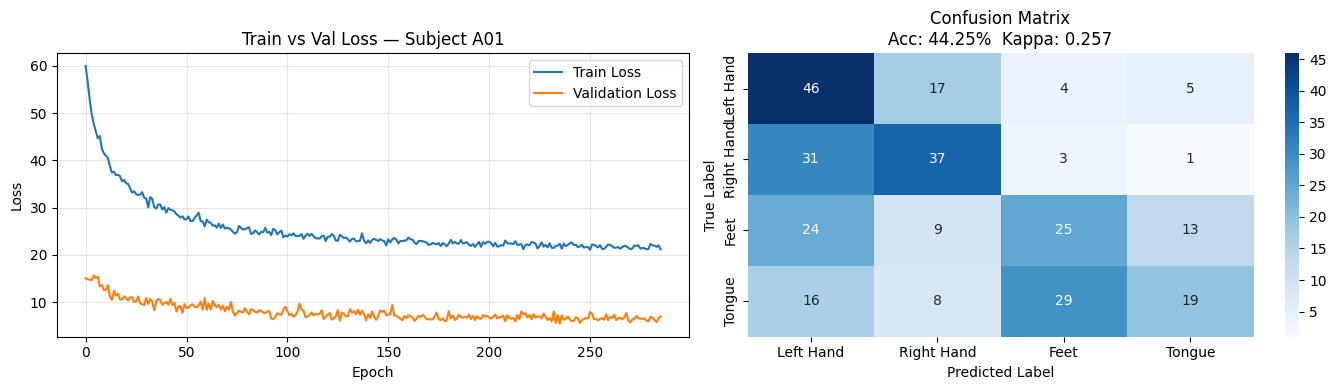

In [14]:
# ── Plot Train vs Validation Loss ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(tr_losses,  label='Train Loss',      linewidth=1.5)
axes[0].plot(val_losses, label='Validation Loss', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Train vs Val Loss — Subject A0{SUBJECT}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(truth, preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_title(f'Confusion Matrix\nAcc: {acc*100:.2f}%  Kappa: {kappa:.3f}')

plt.tight_layout()
plt.show()

## Step 10: All-Subject Loop (Improved)  ← REPLACES OLD STEP 9

Runs the full improved pipeline (augmentation + early stopping) for all 9 subjects.


 Subject A01
Loading train...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Trials found: 288
  Shape: (287, 22, 751) | Classes: {0: 71, 1: 72, 2: 72, 3: 72}
Loading eval...
  True labels: 288 | Classes: {0: 72, 1: 72, 2: 72, 3: 72}


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Cue events (783) in GDF: 288
  Shape: (287, 22, 751)
Augmented train: 287 → 861 trials
  Internal train : 688 trials
  Internal val   : 173 trials
  Official eval  : 287 trials  (held-out)
  Epoch   50 | Train: 28.8774 | Val: 8.8573 | LR: 0.000976
  Epoch  100 | Train: 24.2386 | Val: 6.5647 | LR: 0.000905
  Epoch  150 | Train: 23.3364 | Val: 6.4884 | LR: 0.000794
  Epoch  200 | Train: 22.4778 | Val: 6.2601 | LR: 0.000655
  Early stopping triggered at epoch 210
  Best epoch: 160  Best val loss: 5.4965
  Best model from epoch 160 restored.
  → Accuracy: 43.55%   Kappa: 0.2473

 Subject A02
Loading train...


...

  Cue events (783) in GDF: 288
  Shape: (287, 22, 751)
Augmented train: 287 → 861 trials
  Internal train : 688 trials
  Internal val   : 173 trials
  Official eval  : 287 trials  (held-out)
  Epoch   50 | Train: 29.1288 | Val: 6.7157 | LR: 0.000976
  Epoch  100 | Train: 24.5285 | Val: 5.3769 | LR: 0.000905
  Epoch  150 | Train: 22.3702 | Val: 4.7611 | LR: 0.000794
  Epoch  200 | Train: 23.7468 | Val: 4.6933 | LR: 0.000655
  Epoch  250 | Train: 22.1036 | Val: 4.6757 | LR: 0.000500
  Epoch  300 | Train: 21.2761 | Val: 4.5454 | LR: 0.000345
  Epoch  350 | Train: 21.6619 | Val: 4.5101 | LR: 0.000206
  Early stopping triggered at epoch 357
  Best epoch: 307  Best val loss: 4.2732
  Best model from epoch 307 restored.
  → Accuracy: 43.21%   Kappa: 0.2432

 Subject A09
Loading train...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Trials found: 288
  Shape: (287, 22, 751) | Classes: {0: 72, 1: 72, 2: 71, 3: 72}
Loading eval...
  True labels: 288 | Classes: {0: 72, 1: 72, 2: 72, 3: 72}


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Cue events (783) in GDF: 288
  Shape: (287, 22, 751)
Augmented train: 287 → 861 trials
  Internal train : 688 trials
  Internal val   : 173 trials
  Official eval  : 287 trials  (held-out)
  Epoch   50 | Train: 30.8531 | Val: 7.6655 | LR: 0.000976
  Epoch  100 | Train: 25.9617 | Val: 5.6853 | LR: 0.000905
  Epoch  150 | Train: 24.3061 | Val: 5.6258 | LR: 0.000794
  Epoch  200 | Train: 23.7360 | Val: 4.9630 | LR: 0.000655
  Early stopping triggered at epoch 226
  Best epoch: 176  Best val loss: 4.7206
  Best model from epoch 176 restored.
  → Accuracy: 28.22%   Kappa: 0.0431

Subject        Accuracy      Kappa
--------------------------------------------------
  A01            43.55%      0.2473
  A02            43.21%      0.2427
  A03            62.37%      0.4980
  A04            29.62%      0.0616
  A05            29.27%      0.0581
  A06            31.36%      0.0847
  A07            57.49%      0.4332
  A08            43.21%      0.2432
  A09            28.22%      0.0431
------

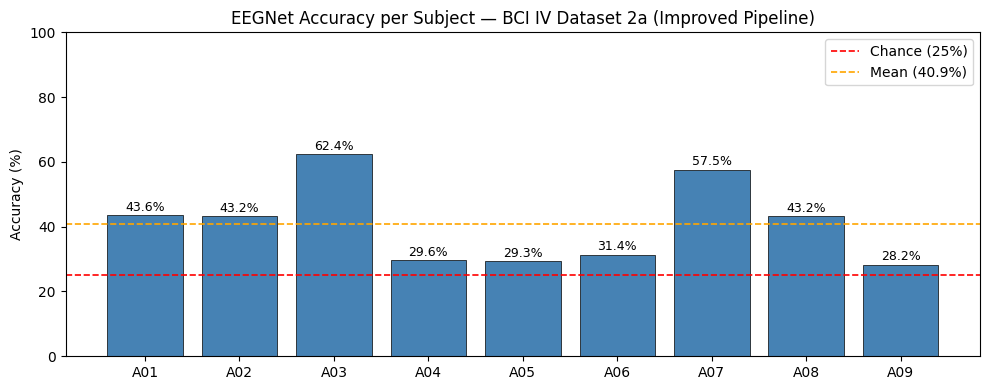

In [15]:
def run_subject_improved(subject_id, data_path, labels_path,
                          epochs=500, patience=50,
                          noise_std=0.05, n_augment=2):
    """
    Full improved pipeline for one subject:
    Load → Normalize → Augment → Train w/ early stopping → Evaluate
    """
    print(f"\n{'='*55}")
    print(f" Subject A0{subject_id}")
    print(f"{'='*55}")

    train_gdf = os.path.join(data_path,  f"A0{subject_id}T.gdf")
    eval_gdf  = os.path.join(data_path,  f"A0{subject_id}E.gdf")
    eval_mat  = os.path.join(labels_path, f"A0{subject_id}E.mat")

    # Load
    print("Loading train...")
    Xt, yt = load_train_data(train_gdf)

    print("Loading eval...")
    Xe, ye = load_eval_data(eval_gdf, eval_mat)

    # Normalize using train stats only
    mean = np.mean(Xt, axis=(0, 2), keepdims=True)
    std  = np.std(Xt,  axis=(0, 2), keepdims=True)
    std  = np.where(std < 1e-8, 1e-8, std)
    Xt   = (Xt - mean) / std
    Xe   = (Xe - mean) / std

    # Add CNN channel dim
    Xt = Xt[:, np.newaxis, :, :]
    Xe = Xe[:, np.newaxis, :, :]

    # Augment training data only
    Xt_aug, yt_aug = augment_eeg(Xt, yt, noise_std=noise_std, n_augment=n_augment)
    print(f"Augmented train: {Xt.shape[0]} → {Xt_aug.shape[0]} trials")

    # Train with early stopping
    acc, kappa, _, _, _, _, _ = train_with_validation(
        Xt_aug, yt_aug,
        Xe, ye,
        device     = device,
        n_channels = Xt.shape[2],
        n_samples  = Xt.shape[3],
        epochs     = epochs,
        patience   = patience
    )

    print(f"  → Accuracy: {acc*100:.2f}%   Kappa: {kappa:.4f}")
    return acc, kappa


# ── Run all 9 subjects ────────────────────────────────────────
results = {}

for sid in range(1, 10):
    try:
        acc, kappa = run_subject_improved(
            sid,
            DATA_PATH,
            TRUE_LABELS_PATH,
            epochs   = 500,
            patience = 50
        )
        results[sid] = {'accuracy': acc, 'kappa': kappa}
    except Exception as e:
        print(f"  Subject A0{sid} FAILED: {e}")
        results[sid] = {'accuracy': None, 'kappa': None}

# ── Summary table ─────────────────────────────────────────────
print("\n" + "="*50)
print(f"{'Subject':<10} {'Accuracy':>12} {'Kappa':>10}")
print("-"*50)

accs, kappas = [], []
for sid, r in results.items():
    if r['accuracy'] is not None:
        print(f"  A0{sid}       {r['accuracy']*100:>10.2f}%  {r['kappa']:>10.4f}")
        accs.append(r['accuracy'])
        kappas.append(r['kappa'])
    else:
        print(f"  A0{sid}            FAILED")

print("-"*50)
if accs:
    print(f"  Mean      {np.mean(accs)*100:>10.2f}%  {np.mean(kappas):>10.4f}")
print("="*50)

# ── Per-subject bar chart ─────────────────────────────────────
if accs:
    sids  = [f"A0{s}" for s, r in results.items() if r['accuracy'] is not None]
    accs_ = [r['accuracy']*100 for r in results.values() if r['accuracy'] is not None]

    plt.figure(figsize=(10, 4))
    bars = plt.bar(sids, accs_, color='steelblue', edgecolor='black', linewidth=0.5)
    plt.axhline(25,            color='red',    linestyle='--', linewidth=1.2, label='Chance (25%)')
    plt.axhline(np.mean(accs_),color='orange', linestyle='--', linewidth=1.2, label=f'Mean ({np.mean(accs_):.1f}%)')
    for bar, val in zip(bars, accs_):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.ylim(0, 100)
    plt.ylabel('Accuracy (%)')
    plt.title('EEGNet Accuracy per Subject — BCI IV Dataset 2a (Improved Pipeline)')
    plt.legend()
    plt.tight_layout()
    plt.show()